In [1]:
##  !pip freeze >> requirements.txt

# Para el gráfico de lineas

In [2]:
#Importación de data
from glob import glob

In [3]:
file_list = glob('*patAcum.csv')
file_list

['DDPG Castigo Correlación 0.5patAcum.csv',
 'DDPG Castigo Correlación 0.7patAcum.csv',
 'DDPG Experimento 1patAcum.csv',
 'DDPG Recompensa de retornopatAcum.csv',
 'DDPG Tamaño Ventana 10patAcum.csv',
 'DDPG Tamaño Ventana 3patAcum.csv',
 'Random AgentpatAcum.csv',
 'SP500 AgentpatAcum.csv']

In [4]:
#Importamos la data (Aca iría la transformación si quiere editar la forma del número (por ejem pasar a miles) o el formato del tiempo)
import pandas as pd
metricsData = {}
for file in file_list:
    df = pd.read_csv(file)
    agentName = df['Serie'][0]
    #(Aquí irian las transformaciones en caso de quererlas)
    metricsData[agentName] = {'dates': df['Time'].to_list() , 'net_worths_delta_acum' : df['patAcum'].to_list()}


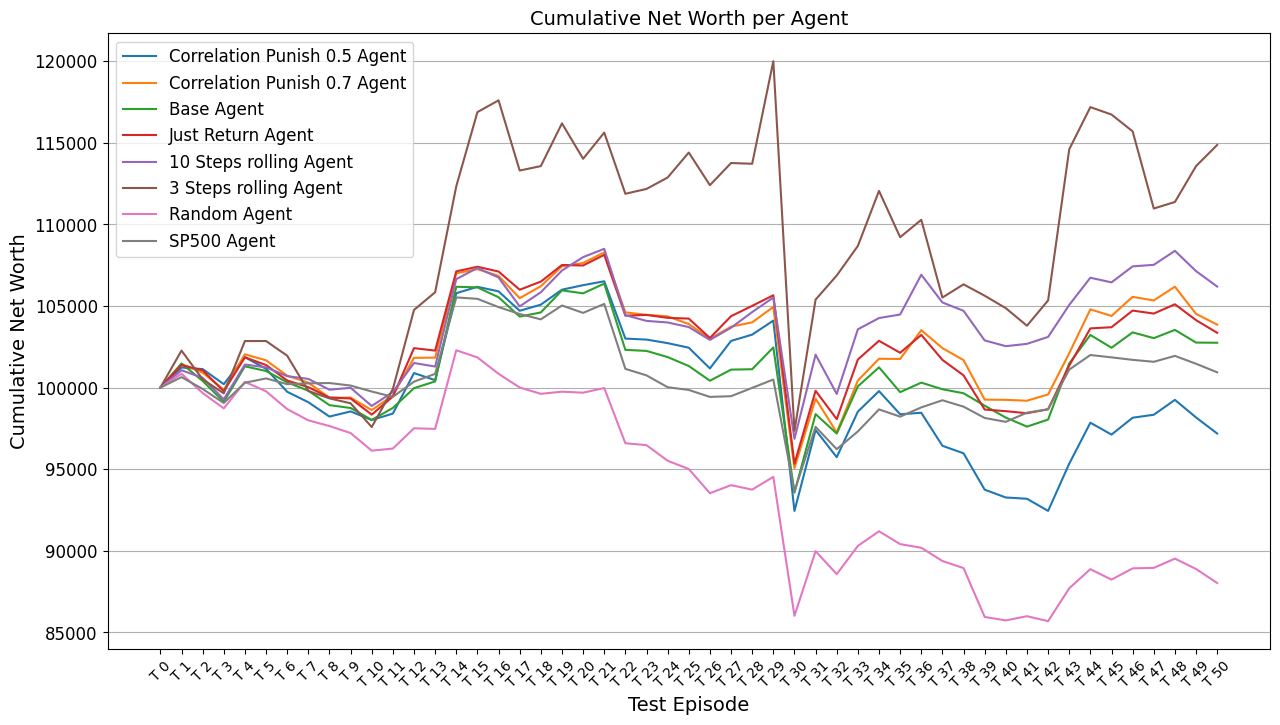

In [5]:
#Argumentos
#label_list_dict = Contiene etiquetas y que nombre quiere ponerles
label_list_dict = {
                   'DDPG Castigo Correlación 0.5' : 'Correlation Punish 0.5 Agent',
                   'DDPG Castigo Correlación 0.7' : 'Correlation Punish 0.7 Agent',
                   'DDPG Experimento 1' : 'Base Agent',
                   'DDPG Recompensa de retorno' : 'Just Return Agent',
                   'DDPG Tamaño Ventana 10' : '10 Steps rolling Agent',
                   'DDPG Tamaño Ventana 3' : '3 Steps rolling Agent',
                   'Random Agent' : 'Random Agent',
                   'SP500 Agent' : 'SP500 Agent',
                   'title': 'Cumulative Net Worth per Agent',
                   'xlabel': 'Test Episode',
                   'ylabel': 'Cumulative Net Worth'}
#path_to_save Prefijo del nombre de la ruta de guardado
path_to_save = 'resumen_total_'
#metrics diccionario que contiene la data, la estructura es:
#  metrics.keys() = lista de nombres de agentes (que coinciden con las llaves del argumento label_list_dict)
#  metrics = {'agent1' : {'dates' : 't_0','t_1',.... , 'net_worths_delta_acum' : 100000, 101264, ...} ,
#             'agent2' : {...... } , ...}


metrics = metricsData

#Creación del Gráfico (Acá para editar el formato)
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 8))
for agent_name, agent_metrics in metrics.items():
    if label_list_dict:
        agent_name = label_list_dict[agent_name]
    plt.plot(agent_metrics['dates'], agent_metrics['net_worths_delta_acum'], label=agent_name)
plt.xticks(rotation=45)
#plt.xticks([])

if label_list_dict:
    plt.title(label_list_dict['title'], fontsize=14)
    plt.xlabel(label_list_dict['xlabel'], fontsize=14)
    plt.ylabel(label_list_dict['ylabel'], fontsize=14)
else:
    plt.title('Cumulative Net Worth Per Test Episode', fontsize=14)
    plt.xlabel('Test Episode', fontsize=14)
    plt.ylabel('Cumulative Net Worth', fontsize=14)
plt.tick_params(axis='y', which='major', labelsize=12)
# increase the legend font size
plt.legend(fontsize=12)
plt.grid(axis='y')

if path_to_save:
    plt.savefig(path_to_save + 'cumulative_net_worth.png')
plt.show()